#### 1. Environment Setup

In [1]:
# Standard library imports
import os
import json
import time
import warnings
from typing import List, Dict, Any, Optional, Tuple
from collections import defaultdict

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from tqdm.auto import tqdm

# Haystack core imports
from haystack import Document, Pipeline
from haystack.document_stores.in_memory import InMemoryDocumentStore
from haystack.components.builders import PromptBuilder
from haystack.components.generators.azure import AzureOpenAIGenerator
from haystack.utils import Secret

# Haystack retrieval imports
from haystack.components.retrievers.in_memory import InMemoryBM25Retriever, InMemoryEmbeddingRetriever
from haystack.components.embedders import (
    SentenceTransformersDocumentEmbedder,
    SentenceTransformersTextEmbedder
)

# Haystack joining and ranking
from haystack.components.joiners import DocumentJoiner
from haystack.components.rankers import (
    TransformersSimilarityRanker,
    LostInTheMiddleRanker
)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful!")

✅ All imports successful!


#### 2. Dense Embeddings & Semantic Search

In [2]:
text_embedder = SentenceTransformersTextEmbedder(model="sentence-transformers/all-MiniLM-L6-v2")
text_embedder.warm_up()

texts = [
    "The cat sat on the mat",
    "A feline rested on the rug",  # Similar meaning
    "Python is a programming language",  # Different meaning
]
print("Creating embeddings...\n")
embeddings = []
for text in texts:
    result = text_embedder.run(text=text)
    embedding = result['embedding']
    embeddings.append(embedding)
    print(f"Text: {text}")
    print(f"Embedding shape: {np.array(embedding).shape}")
    print(f"First 5 values: {embedding[:5]}\n")

The `tokenizer_kwargs` argument was renamed and is now deprecated. Please use `processor_kwargs` instead.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Creating embeddings...



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Text: The cat sat on the mat
Embedding shape: (384,)
First 5 values: [0.13040189445018768, -0.011870157904922962, -0.028117012232542038, 0.05123864486813545, -0.05597449839115143]



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Text: A feline rested on the rug
Embedding shape: (384,)
First 5 values: [0.0721820667386055, 0.04459076374769211, 0.0539359450340271, 0.12767881155014038, 0.002133664907887578]



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Text: Python is a programming language
Embedding shape: (384,)
First 5 values: [-0.03537086397409439, 0.03816498443484306, -0.04126005992293358, 0.016068819910287857, -0.038367077708244324]



In [3]:
def cosine_similarity(vec1: List[float], vec2: List[float])-> float:
    """
    Calculate cosine similarity between two vectors.
    Returns value between -1 (opposite) and 1 (identical).
    """
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)
    return np.dot(vec1,vec2)/(np.linalg.norm(vec1)*np.linalg.norm(vec2))

# Calculate similarities
print("Cosine Similarities:\n")
print(f"Text 1 vs Text 2 (similar meaning): {cosine_similarity(embeddings[0], embeddings[1]):.4f}")
print(f"Text 1 vs Text 3 (different meaning): {cosine_similarity(embeddings[0], embeddings[2]):.4f}")
print(f"Text 2 vs Text 3 (different meaning): {cosine_similarity(embeddings[1], embeddings[2]):.4f}")

print("\n💡 Higher similarity score = more semantically similar!")

Cosine Similarities:

Text 1 vs Text 2 (similar meaning): 0.5643
Text 1 vs Text 3 (different meaning): 0.0309
Text 2 vs Text 3 (different meaning): 0.0633

💡 Higher similarity score = more semantically similar!


##### Prepare Dataset for Semantic Search

In [4]:
def generate_ml_wikipedia_articles() -> List[Document]:
    """
    Generate sample Wikipedia-style articles about machine learning topics.
    In a real scenario, you'd load these from a dataset.
    """
    articles = [
        {
            "title": "Neural Networks",
            "content": """Neural networks are computing systems inspired by biological neural networks. 
            They consist of interconnected nodes (neurons) organized in layers. Information flows through 
            the network, with each connection having an associated weight. Training adjusts these weights 
            to minimize prediction error. Common architectures include feedforward networks, convolutional 
            neural networks (CNNs), and recurrent neural networks (RNNs).""",
            "category": "Deep Learning"
        },
        {
            "title": "Random Forest",
            "content": """Random Forest is an ensemble learning method that constructs multiple decision 
            trees during training. For classification, it outputs the mode of the classes from individual 
            trees. For regression, it outputs the mean prediction. The algorithm introduces randomness in 
            two ways: bootstrap sampling of training data and random feature selection at each split. 
            This reduces overfitting compared to single decision trees.""",
            "category": "Machine Learning"
        },
        {
            "title": "Gradient Descent",
            "content": """Gradient descent is an optimization algorithm used to minimize loss functions. 
            It iteratively moves in the direction of steepest descent, defined by the negative gradient. 
            The learning rate controls step size. Variants include batch gradient descent (uses all data), 
            stochastic gradient descent (uses one sample), and mini-batch gradient descent (uses small batches). 
            Adam and RMSprop are advanced adaptive learning rate methods.""",
            "category": "Optimization"
        },
        {
            "title": "Support Vector Machines",
            "content": """Support Vector Machines (SVM) are supervised learning models for classification 
            and regression. SVMs find the optimal hyperplane that maximizes the margin between classes. 
            Support vectors are data points closest to the hyperplane. The kernel trick allows SVMs to 
            handle non-linear decision boundaries by implicitly mapping data to higher dimensions. 
            Common kernels include linear, polynomial, and radial basis function (RBF).""",
            "category": "Machine Learning"
        },
        {
            "title": "Convolutional Neural Networks",
            "content": """Convolutional Neural Networks (CNNs) are deep learning models designed for 
            processing grid-like data such as images. Key components include convolutional layers (apply 
            filters to detect features), pooling layers (downsample to reduce dimensions), and fully 
            connected layers (perform classification). CNNs automatically learn hierarchical features, 
            from edges to complex patterns. Popular architectures include LeNet, AlexNet, VGG, and ResNet.""",
            "category": "Deep Learning"
        },
        {
            "title": "K-Means Clustering",
            "content": """K-Means is an unsupervised learning algorithm that partitions data into K clusters. 
            The algorithm iteratively assigns points to nearest centroid and updates centroids as cluster means. 
            Initialization methods like K-Means++ improve convergence. The elbow method helps determine optimal K. 
            K-Means assumes spherical clusters of similar size and struggles with irregular shapes. 
            Alternatives include DBSCAN and hierarchical clustering.""",
            "category": "Unsupervised Learning"
        },
        {
            "title": "Transformer Architecture",
            "content": """Transformers revolutionized NLP through self-attention mechanisms. Unlike RNNs, 
            they process entire sequences in parallel. Key components include multi-head attention (captures 
            different relationships), positional encoding (preserves sequence order), and feedforward networks. 
            The encoder-decoder structure enables seq2seq tasks. BERT uses encoder-only, GPT uses decoder-only. 
            Transformers scale effectively and form the basis of large language models.""",
            "category": "Deep Learning"
        },
        {
            "title": "Principal Component Analysis",
            "content": """Principal Component Analysis (PCA) is a dimensionality reduction technique that 
            identifies principal components - orthogonal directions of maximum variance. PCA projects data 
            onto lower-dimensional space while preserving most variance. It's computed via eigenvalue 
            decomposition of covariance matrix. Applications include visualization, noise reduction, and 
            feature extraction. PCA assumes linear relationships; alternatives include t-SNE and UMAP.""",
            "category": "Dimensionality Reduction"
        },
        {
            "title": "Reinforcement Learning",
            "content": """Reinforcement Learning (RL) trains agents to make decisions through trial and error. 
            An agent interacts with environment, receiving rewards for actions. The goal is to learn a policy 
            maximizing cumulative reward. Q-Learning learns action values, policy gradient methods directly 
            optimize policy. Deep RL combines neural networks with RL, enabling complex tasks like game playing. 
            Notable algorithms include DQN, A3C, and PPO.""",
            "category": "Reinforcement Learning"
        },
        {
            "title": "Decision Trees",
            "content": """Decision trees are supervised learning models that split data based on feature values. 
            Each internal node represents a test, branches represent outcomes, and leaves represent predictions. 
            Common splitting criteria include Gini impurity and information gain (entropy reduction). 
            Trees are interpretable and handle non-linear relationships but prone to overfitting. 
            Pruning techniques and ensemble methods like Random Forest address this limitation.""",
            "category": "Machine Learning"
        },
        {
            "title": "Recurrent Neural Networks",
            "content": """Recurrent Neural Networks (RNNs) process sequential data by maintaining hidden state. 
            Information from previous timesteps influences current predictions through recurrent connections. 
            Vanilla RNNs suffer from vanishing gradients in long sequences. LSTM (Long Short-Term Memory) 
            and GRU (Gated Recurrent Unit) use gating mechanisms to remember long-term dependencies. 
            Applications include language modeling, machine translation, and time series prediction.""",
            "category": "Deep Learning"
        },
        {
            "title": "Logistic Regression",
            "content": """Logistic regression is a statistical model for binary classification. Despite its name, 
            it's a classification algorithm. It models probability using the sigmoid function, producing outputs 
            between 0 and 1. Training maximizes likelihood via gradient descent. Multinomial logistic regression 
            extends to multiple classes. Regularization (L1/L2) prevents overfitting. Logistic regression is 
            interpretable, fast, and serves as baseline for classification tasks.""",
            "category": "Machine Learning"
        }
    ]
    return [
        Document(
            content = article["content"],
            meta={
                "title": article["title"],
                "category": article["category"],
                "source": "ml_wikipedia"  
            }
        ) for article in articles
    ]

ml_articles = generate_ml_wikipedia_articles()
print(f"✅ Generated {len(ml_articles)} ML articles")
print("\nSample article:")
print(f"Title: {ml_articles[0].meta['title']}")
print(f"Category: {ml_articles[0].meta['category']}")
print(f"Content: {ml_articles[0].content[:150]}...")

✅ Generated 12 ML articles

Sample article:
Title: Neural Networks
Category: Deep Learning
Content: Neural networks are computing systems inspired by biological neural networks. 
            They consist of interconnected nodes (neurons) organized in...


##### Build Semantic Search Pipeline

In [5]:
semantic_store = InMemoryDocumentStore()

print("Initializing document embedder...")
doc_embedder = SentenceTransformersDocumentEmbedder(model="sentence-transformers/all-MiniLM-L6-v2")
doc_embedder.warm_up()

print("\nEmbedding documents (this may take a moment)...")
embedded_docs = doc_embedder.run(documents=ml_articles)

semantic_store.write_documents(embedded_docs['documents'])

print(f"✅ Embedded and stored {semantic_store.count_documents()} documents")
print(f"\nEmbedding dimension: {len(embedded_docs['documents'][0].embedding)} dimensions")

Initializing document embedder...

Embedding documents (this may take a moment)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Embedded and stored 12 documents

Embedding dimension: 384 dimensions


In [6]:
semantic_pipeline = Pipeline()

semantic_pipeline.add_component(
    "text_embedder", 
    SentenceTransformersTextEmbedder(model="sentence-transformers/all-MiniLM-L6-v2")
)
semantic_pipeline.add_component(
    "retriever",
    InMemoryEmbeddingRetriever(document_store=semantic_store)
)
semantic_pipeline.connect("text_embedder.embedding", "retriever.query_embedding")

print("✅ Semantic search pipeline created")
print("\nPipeline structure:")
print(semantic_pipeline)

✅ Semantic search pipeline created

Pipeline structure:
🚅 Components
  - text_embedder: SentenceTransformersTextEmbedder
  - retriever: InMemoryEmbeddingRetriever
🛤️ Connections
  - text_embedder.embedding -> retriever.query_embedding (list[float])



In [7]:
bm25_store = InMemoryDocumentStore()
bm25_store.write_documents(ml_articles)

bm25_pipeline = Pipeline()
bm25_pipeline.add_component("retriever", InMemoryBM25Retriever(document_store=bm25_store))

print("✅ BM25 pipeline created for comparison")

✅ BM25 pipeline created for comparison


In [8]:
def compare_retrieval_methods(query: str, top_k: int = 3):
    """
    Compare BM25 and semantic search side-by-side.
    """

    print("\n" + "="*100)
    print(f"Query: '{query}'")
    print("="*100)

    bm25_results = bm25_pipeline.run({
        "retriever": {"query": query, "top_k": top_k}
    })

    semantic_results = semantic_pipeline.run({
        "text_embedder": {"text": query},
        "retriever": {"top_k": top_k}
    })

    print("\n" + "-"*50 + " BM25 (Keyword) " + "-"*50)
    for i, doc in enumerate(bm25_results['retriever']['documents'], 1):
        print(f"\n{i}. {doc.meta['title']} (score: {doc.score:.4f})")
        print(f"   Category: {doc.meta['category']}")
        print(f"   Content: {doc.content[:120]}...")
    
    print("\n" + "-"*50 + " Semantic (Embeddings) " + "-"*50)
    for i, doc in enumerate(semantic_results['retriever']['documents'], 1):
        print(f"\n{i}. {doc.meta['title']} (score: {doc.score:.4f})")
        print(f"   Category: {doc.meta['category']}")
        print(f"   Content: {doc.content[:120]}...")

test_queries = [
    "How do artificial brains learn?",  # Semantic: Neural Networks
    "Organizing data into groups without labels",  # Semantic: K-Means
    "Image recognition deep learning",  # Semantic: CNNs
]
for query in test_queries:
    compare_retrieval_methods(query)


Query: 'How do artificial brains learn?'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


-------------------------------------------------- BM25 (Keyword) --------------------------------------------------

1. Convolutional Neural Networks (score: 2.0771)
   Category: Deep Learning
   Content: Convolutional Neural Networks (CNNs) are deep learning models designed for 
            processing grid-like data such a...

2. Reinforcement Learning (score: 2.0338)
   Category: Reinforcement Learning
   Content: Reinforcement Learning (RL) trains agents to make decisions through trial and error. 
            An agent interacts wit...

3. Neural Networks (score: 1.0304)
   Category: Deep Learning
   Content: Neural networks are computing systems inspired by biological neural networks. 
            They consist of interconnecte...

-------------------------------------------------- Semantic (Embeddings) --------------------------------------------------

1. Neural Networks (score: 0.4424)
   Category: Deep Learning
   Content: Neural networks are computing systems inspired by biolo

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


-------------------------------------------------- BM25 (Keyword) --------------------------------------------------

1. K-Means Clustering (score: 3.2146)
   Category: Unsupervised Learning
   Content: K-Means is an unsupervised learning algorithm that partitions data into K clusters. 
            The algorithm iterative...

2. Support Vector Machines (score: 2.0106)
   Category: Machine Learning
   Content: Support Vector Machines (SVM) are supervised learning models for classification 
            and regression. SVMs find t...

3. Principal Component Analysis (score: 1.8873)
   Category: Dimensionality Reduction
   Content: Principal Component Analysis (PCA) is a dimensionality reduction technique that 
            identifies principal compon...

-------------------------------------------------- Semantic (Embeddings) --------------------------------------------------

1. K-Means Clustering (score: 0.3120)
   Category: Unsupervised Learning
   Content: K-Means is an unsupervised l

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


-------------------------------------------------- BM25 (Keyword) --------------------------------------------------

1. Reinforcement Learning (score: 2.8831)
   Category: Reinforcement Learning
   Content: Reinforcement Learning (RL) trains agents to make decisions through trial and error. 
            An agent interacts wit...

2. Convolutional Neural Networks (score: 2.7701)
   Category: Deep Learning
   Content: Convolutional Neural Networks (CNNs) are deep learning models designed for 
            processing grid-like data such a...

3. Gradient Descent (score: 1.8797)
   Category: Optimization
   Content: Gradient descent is an optimization algorithm used to minimize loss functions. 
            It iteratively moves in the ...

-------------------------------------------------- Semantic (Embeddings) --------------------------------------------------

1. Convolutional Neural Networks (score: 0.5740)
   Category: Deep Learning
   Content: Convolutional Neural Networks (CNNs) are 

In [9]:
hybrid_store = InMemoryDocumentStore()
hybrid_store.write_documents(embedded_docs['documents'])

hybrid_pipeline = Pipeline()
hybrid_pipeline.add_component(
    "text_embedder",
    SentenceTransformersTextEmbedder(model="sentence-transformers/all-MiniLM-L6-v2")
)

hybrid_pipeline.add_component(
    "bm25_retriever",
    InMemoryBM25Retriever(document_store=hybrid_store)  
)
hybrid_pipeline.add_component(
    "embedding_retriever",
    InMemoryEmbeddingRetriever(document_store=hybrid_store)
)

hybrid_pipeline.add_component(
    "joiner",
    DocumentJoiner(join_mode="reciprocal_rank_fusion")
)
hybrid_pipeline.connect("text_embedder.embedding", "embedding_retriever.query_embedding")
hybrid_pipeline.connect("bm25_retriever", "joiner")
hybrid_pipeline.connect("embedding_retriever", "joiner")

print("✅ Hybrid retrieval pipeline created")
print("\nPipeline structure:")
print(hybrid_pipeline)

✅ Hybrid retrieval pipeline created

Pipeline structure:
🚅 Components
  - text_embedder: SentenceTransformersTextEmbedder
  - bm25_retriever: InMemoryBM25Retriever
  - embedding_retriever: InMemoryEmbeddingRetriever
  - joiner: DocumentJoiner
🛤️ Connections
  - text_embedder.embedding -> embedding_retriever.query_embedding (list[float])
  - bm25_retriever.documents -> joiner.documents (list[Document])
  - embedding_retriever.documents -> joiner.documents (list[Document])



In [10]:
def test_hybrid_retrieval(query: str, top_k: int = 5):
    """
    Test hybrid retrieval and show results from both retrievers.
    """
    print("\n" + "="*100)
    print(f"Query: '{query}'")
    print("="*100)

    result = hybrid_pipeline.run({
        "text_embedder": {"text": query},
        "bm25_retriever": {"query": query, "top_k": top_k},
        "embedding_retriever": {"top_k": top_k}        
    })
    print("\n🔍 Hybrid Retrieval Results (Reciprocal Rank Fusion):\n")
    for i, doc in enumerate(result['joiner']['documents'][:top_k], 1):
        print(f"{i}. {doc.meta['title']} (RRF score: {doc.score:.4f})")
        print(f"   Category: {doc.meta['category']}")
        print(f"   {doc.content[:100]}...\n")

test_queries = [
    "neural network architecture for images",
    "tree-based ensemble methods",
    "optimization algorithms for training models"
]
for query in test_queries:
    test_hybrid_retrieval(query)


Query: 'neural network architecture for images'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Hybrid Retrieval Results (Reciprocal Rank Fusion):

1. Neural Networks (RRF score: 1.0000)
   Category: Deep Learning
   Neural networks are computing systems inspired by biological neural networks. 
            They cons...

2. Convolutional Neural Networks (RRF score: 0.9839)
   Category: Deep Learning
   Convolutional Neural Networks (CNNs) are deep learning models designed for 
            processing g...

3. Reinforcement Learning (RRF score: 0.9607)
   Category: Reinforcement Learning
   Reinforcement Learning (RL) trains agents to make decisions through trial and error. 
            An...

4. Recurrent Neural Networks (RRF score: 0.4841)
   Category: Deep Learning
   Recurrent Neural Networks (RNNs) process sequential data by maintaining hidden state. 
            I...

5. Random Forest (RRF score: 0.4766)
   Category: Machine Learning
   Random Forest is an ensemble learning method that constructs multiple decision 
            trees du...


Query: 'tree-based ensemble metho

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Hybrid Retrieval Results (Reciprocal Rank Fusion):

1. Decision Trees (RRF score: 0.9919)
   Category: Machine Learning
   Decision trees are supervised learning models that split data based on feature values. 
            ...

2. Random Forest (RRF score: 0.9919)
   Category: Machine Learning
   Random Forest is an ensemble learning method that constructs multiple decision 
            trees du...

3. K-Means Clustering (RRF score: 0.9683)
   Category: Unsupervised Learning
   K-Means is an unsupervised learning algorithm that partitions data into K clusters. 
            The...

4. Gradient Descent (RRF score: 0.4766)
   Category: Optimization
   Gradient descent is an optimization algorithm used to minimize loss functions. 
            It itera...

5. Support Vector Machines (RRF score: 0.4766)
   Category: Machine Learning
   Support Vector Machines (SVM) are supervised learning models for classification 
            and reg...


Query: 'optimization algorithms for training mode

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Hybrid Retrieval Results (Reciprocal Rank Fusion):

1. Gradient Descent (RRF score: 0.9766)
   Category: Optimization
   Gradient descent is an optimization algorithm used to minimize loss functions. 
            It itera...

2. Random Forest (RRF score: 0.9612)
   Category: Machine Learning
   Random Forest is an ensemble learning method that constructs multiple decision 
            trees du...

3. Logistic Regression (RRF score: 0.5000)
   Category: Machine Learning
   Logistic regression is a statistical model for binary classification. Despite its name, 
           ...

4. Support Vector Machines (RRF score: 0.4919)
   Category: Machine Learning
   Support Vector Machines (SVM) are supervised learning models for classification 
            and reg...

5. Reinforcement Learning (RRF score: 0.4841)
   Category: Reinforcement Learning
   Reinforcement Learning (RL) trains agents to make decisions through trial and error. 
            An...



In [11]:
def comprehensive_comparision(query: str, top_k: int=3):

    """
    Compare BM25, Semantic, and Hybrid retrieval.
    """
    print("\n" + "="*100)
    print(f"COMPREHENSIVE COMPARISON: '{query}'")
    print("="*100)

    bm25_result = bm25_pipeline.run({"retriever": {"query": query, "top_k": top_k}})

    semantic_result = semantic_pipeline.run({
        "text_embedder": {"text": query},
        "retriever": {"top_k": top_k}
    })
    hybrid_result = hybrid_pipeline.run({
        "text_embedder": {"text": query},
        "bm25_retriever": {"query": query, "top_k": top_k},
        "embedding_retriever": {"top_k": top_k}
    })

    methods = ['BM25', 'Semantic', 'Hybrid']
    results = [
        bm25_result['retriever']['documents'],
        semantic_result['retriever']['documents'],
        hybrid_result['joiner']['documents'][:top_k]
    ]
    data = []
    for method, docs in zip(methods, results):
        for rank, doc in enumerate(docs,1):
            data.append({
                'Method': method,
                'Rank': rank,
                'Title': doc.meta['title'],
                'Score': f"{doc.score:.4f}"
            })
    df = pd.DataFrame(data)
    for method in methods:
        print(f"\n{method}: ")
        method_df = df[df['Method']==method][['Rank', 'Title', 'Score']]
        print(method_df.to_string(index=False))

comprehensive_comparision("supervised classification algorithm")
comprehensive_comparision("attention mechanism in NLP")



COMPREHENSIVE COMPARISON: 'supervised classification algorithm'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


BM25: 
 Rank                   Title  Score
    1     Logistic Regression 4.1995
    2 Support Vector Machines 4.0333
    3           Random Forest 3.6696

Semantic: 
 Rank                   Title  Score
    1 Support Vector Machines 0.5397
    2          Decision Trees 0.4770
    3           Random Forest 0.4070

Hybrid: 
 Rank                   Title  Score
    1 Support Vector Machines 0.9919
    2           Random Forest 0.9683
    3     Logistic Regression 0.5000

COMPREHENSIVE COMPARISON: 'attention mechanism in NLP'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


BM25: 
 Rank                     Title  Score
    1  Transformer Architecture 7.1731
    2           Neural Networks 3.8026
    3 Recurrent Neural Networks 3.7784

Semantic: 
 Rank                     Title  Score
    1  Transformer Architecture 0.4953
    2 Recurrent Neural Networks 0.3388
    3           Neural Networks 0.2521

Hybrid: 
 Rank                     Title  Score
    1  Transformer Architecture 1.0000
    2           Neural Networks 0.9761
    3 Recurrent Neural Networks 0.9761


#### 4. Query Expansion Techniques

In [12]:
def query_expansion_with_llm(original_query: str, num_variations: int=3):
    """
    Use an LLM to generate query variations.
    """
    prompt = f"""Generate {num_variations} alternative phrasings of this search query.
Each variation should ask for the same information but use different words.

Original query: {original_query}

Provide only the alternative queries, one per line, without numbering or explanations.
"""
    llm = AzureOpenAIGenerator(
        api_key=Secret.from_env_var("AZURE_OPENAI_API_KEY"),
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
        api_version="2024-12-01-preview",
        generation_kwargs={"temperature": 0.3},
    )
    result = llm.run(prompt=prompt)
    variations = result['replies'][0].strip().split('\n')
    variations = [v.strip() for v in variations if v.strip()]

    return [original_query] + variations[:num_variations]

original = "How do neural networks learn?"
expanded = query_expansion_with_llm(original, num_variations=3)

print("Query Expansion Example:\n")
print(f"Original: {original}\n")
print("Expanded queries:")
for i, query in enumerate(expanded[1:], 1):
    print(f"{i}. {query}")

Query Expansion Example:

Original: How do neural networks learn?

Expanded queries:
1. What is the process by which neural networks acquire knowledge?
2. How do neural networks train and improve their performance?
3. What mechanisms allow neural networks to learn from data?


In [13]:
def retrieve_with_query_expansion(query: str, top_k: int = 5) -> List[Document]:
    """
    Perform retrieval with query expansion.
    Retrieves results for multiple query variations and combines them.
    """
    expanded_queries = query_expansion_with_llm(query)
    for i, q in enumerate(expanded_queries,1):
        print(f"{i}. {q}")
    
    all_docs = []
    doc_scores = defaultdict(float)
    for exp_query in expanded_queries:
        result = hybrid_pipeline.run({
            "text_embedder": {"text": exp_query},
            "bm25_retriever": {"query": exp_query, "top_k": top_k},
            "embedding_retriever": {"top_k": top_k},
        })
        for doc in result['joiner']['documents']:
            doc_scores[doc.id] = max(doc_scores[doc.id], doc.score)
            if doc.id not in [d.id for d in all_docs]:
                all_docs.append(doc)
    
    all_docs.sort(key=lambda d: doc_scores[d.id], reverse=True)

    return all_docs[:top_k]


print("\n" + "="*100)
print("RETRIEVAL WITH QUERY EXPANSION")
print("="*100)

query = "clustering algorithm"
results = retrieve_with_query_expansion(query, top_k=5)

print("\n📊 Final Results:\n")
for i, doc in enumerate(results, 1):
    print(f"{i}. {doc.meta['title']}")
    print(f"   {doc.content[:100]}...\n")


RETRIEVAL WITH QUERY EXPANSION
1. clustering algorithm
2. clustering methods
3. grouping algorithms
4. cluster analysis techniques


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


📊 Final Results:

1. K-Means Clustering
   K-Means is an unsupervised learning algorithm that partitions data into K clusters. 
            The...

2. Principal Component Analysis
   Principal Component Analysis (PCA) is a dimensionality reduction technique that 
            identif...

3. Random Forest
   Random Forest is an ensemble learning method that constructs multiple decision 
            trees du...

4. Decision Trees
   Decision trees are supervised learning models that split data based on feature values. 
            ...

5. Support Vector Machines
   Support Vector Machines (SVM) are supervised learning models for classification 
            and reg...



#### Reranking Strategies

In [14]:
#!uv pip install "transformers[torch,sentencepiece]" accelerate

In [16]:
rerank_pipeline = Pipeline()

rerank_pipeline.add_component(
    "text_embedder",
    SentenceTransformersTextEmbedder(model="sentence-transformers/all-MiniLM-L6-v2")
)
rerank_pipeline.add_component(
    "retriever",
    InMemoryEmbeddingRetriever(document_store=semantic_store)
),
rerank_pipeline.add_component(
    "reranker",
    TransformersSimilarityRanker(model="cross-encoder/ms-marco-MiniLM-L-6-v2")
)
rerank_pipeline.connect("text_embedder.embedding", "retriever.query_embedding")
rerank_pipeline.connect("retriever", "reranker")

print("✅ Pipeline with reranking created")

TransformersSimilarityRanker is considered legacy and will no longer receive updates. It may be deprecated in a future release, with removal following after a deprecation period. Consider using SentenceTransformersSimilarityRanker instead, which provides the same functionality along with additional features.


✅ Pipeline with reranking created


In [18]:
def compare_with_without_reranking(query: str, top_k_retrieve: int = 10, top_k_final: int = 5):
    """
    Compare retrieval with and without reranking.
    """
    print("\n" + "="*100)
    print(f"Query: '{query}'")
    print("="*100)

    without_rerank = semantic_pipeline.run({
        "text_embedder": {"text": query},
        "retriever": {"top_k": top_k_final}
    })

    with_rerank = rerank_pipeline.run({
        "text_embedder": {"text": query},
        "retriever": {"top_k": top_k_retrieve},
        "reranker": {"query": query, "top_k": top_k_final}
    })
    print("\n" + "-"*45 + " WITHOUT Reranking " + "-"*45)
    for i, doc in enumerate(without_rerank['retriever']['documents'], 1):
        print(f"{i}. {doc.meta['title']} (score: {doc.score:.4f})")
    
    print("\n" + "-"*45 + " WITH Reranking " + "-"*45)
    for i, doc in enumerate(with_rerank['ranker']['documents'], 1):
        print(f"{i}. {doc.meta['title']} (score: {doc.score:.4f})")

compare_with_without_reranking("deep learning for computer vision")
compare_with_without_reranking("unsupervised learning techniques")



Query: 'deep learning for computer vision'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


--------------------------------------------- WITHOUT Reranking ---------------------------------------------
1. Convolutional Neural Networks (score: 0.5232)
2. Neural Networks (score: 0.3635)
3. Recurrent Neural Networks (score: 0.2973)
4. Reinforcement Learning (score: 0.2819)
5. Support Vector Machines (score: 0.2549)

--------------------------------------------- WITH Reranking ---------------------------------------------


KeyError: 'ranker'

In [19]:
litm_pipeline = Pipeline()

litm_pipeline.add_component(
    "text_embedder",
    SentenceTransformersTextEmbedder(model="sentence-transformers/all-MiniLM-L6-v2")
)
litm_pipeline.add_component(
    "retriever",
    InMemoryEmbeddingRetriever(document_store=semantic_store)
)
litm_pipeline.add_component(
    "ranker",
    LostInTheMiddleRanker(word_count_threshold=1024)  # Reorder long contexts
)

litm_pipeline.connect("text_embedder.embedding", "retriever.query_embedding")
litm_pipeline.connect("retriever", "ranker")

print("✅ Lost in the Middle ranker pipeline created")
print("\nThis ranker reorders documents to place most relevant ones at beginning and end,")
print("avoiding the 'lost in the middle' problem where LLMs miss mid-context information.")

✅ Lost in the Middle ranker pipeline created

This ranker reorders documents to place most relevant ones at beginning and end,
avoiding the 'lost in the middle' problem where LLMs miss mid-context information.


In [20]:
def create_evaluation_dataset() -> List[Dict[str, Any]]:
    """
    Create evaluation dataset with queries and relevant document titles.
    """
    return [
        {
            "query": "How do artificial neural networks process information?",
            "relevant_docs": ["Neural Networks", "Convolutional Neural Networks", "Recurrent Neural Networks"]
        },
        {
            "query": "What is an ensemble method that uses multiple decision trees?",
            "relevant_docs": ["Random Forest", "Decision Trees"]
        },
        {
            "query": "Optimization algorithm for training machine learning models",
            "relevant_docs": ["Gradient Descent"]
        },
        {
            "query": "Dimensionality reduction technique for visualization",
            "relevant_docs": ["Principal Component Analysis"]
        },
        {
            "query": "Deep learning architecture for image recognition",
            "relevant_docs": ["Convolutional Neural Networks", "Neural Networks"]
        },
        {
            "query": "Unsupervised learning for grouping similar data",
            "relevant_docs": ["K-Means Clustering"]
        },
        {
            "query": "Model for binary classification problems",
            "relevant_docs": ["Logistic Regression", "Support Vector Machines", "Decision Trees"]
        },
        {
            "query": "Learning through rewards and penalties",
            "relevant_docs": ["Reinforcement Learning"]
        }
    ]

eval_dataset = create_evaluation_dataset()
print(f"✅ Created evaluation dataset with {len(eval_dataset)} queries")
print("\nSample evaluation case:")
print(f"Query: {eval_dataset[0]['query']}")
print(f"Relevant docs: {eval_dataset[0]['relevant_docs']}")

✅ Created evaluation dataset with 8 queries

Sample evaluation case:
Query: How do artificial neural networks process information?
Relevant docs: ['Neural Networks', 'Convolutional Neural Networks', 'Recurrent Neural Networks']


In [21]:
def calculate_recall_at_k(retrieved_titles: List[str], relevant_titles: List[str], k: int) -> float:
    """
    Calculate Recall@K: fraction of relevant documents retrieved in top K.
    """
    retrieved_set = set(retrieved_titles[:k])
    relevant_set = set(relevant_titles)
    
    if not relevant_set:
        return 0.0
    
    relevant_retrieved = retrieved_set.intersection(relevant_set)
    return len(relevant_retrieved) / len(relevant_set)

def calculate_precision_at_k(retrieved_titles: List[str], relevant_titles: List[str], k: int) -> float:
    """
    Calculate Precision@K: fraction of retrieved documents that are relevant.
    """
    retrieved_set = set(retrieved_titles[:k])
    relevant_set = set(relevant_titles)
    
    if not retrieved_set:
        return 0.0
    
    relevant_retrieved = retrieved_set.intersection(relevant_set)
    return len(relevant_retrieved) / len(retrieved_set)

def calculate_mrr(retrieved_titles: List[str], relevant_titles: List[str]) -> float:
    """
    Calculate Mean Reciprocal Rank: 1/rank of first relevant document.
    """
    relevant_set = set(relevant_titles)
    
    for i, title in enumerate(retrieved_titles, 1):
        if title in relevant_set:
            return 1.0 / i
    
    return 0.0

def calculate_ndcg_at_k(retrieved_titles: List[str], relevant_titles: List[str], k: int) -> float:
    """
    Calculate Normalized Discounted Cumulative Gain@K.
    """
    relevant_set = set(relevant_titles)
    
    # DCG: sum of (relevance / log2(position + 1))
    dcg = 0.0
    for i, title in enumerate(retrieved_titles[:k], 1):
        relevance = 1.0 if title in relevant_set else 0.0
        dcg += relevance / np.log2(i + 1)
    
    # IDCG: best possible DCG
    idcg = 0.0
    for i in range(min(len(relevant_titles), k)):
        idcg += 1.0 / np.log2(i + 2)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg

print("✅ Evaluation metrics implemented:")
print("  • Recall@K")
print("  • Precision@K")
print("  • Mean Reciprocal Rank (MRR)")
print("  • Normalized Discounted Cumulative Gain (NDCG@K)")


✅ Evaluation metrics implemented:
  • Recall@K
  • Precision@K
  • Mean Reciprocal Rank (MRR)
  • Normalized Discounted Cumulative Gain (NDCG@K)


In [22]:
def evaluate_retrieval_system(pipeline, dataset: List[Dict], k_values: List[int] = [1, 3, 5]):
    """
    Comprehensive evaluation of a retrieval system.
    """
    results = {
        'recall': {k: [] for k in k_values},
        'precision': {k: [] for k in k_values},
        'ndcg': {k: [] for k in k_values},
        'mrr': []
    }
    
    print(f"\nEvaluating on {len(dataset)} queries...")
    
    for eval_case in tqdm(dataset):
        query = eval_case['query']
        relevant_titles = eval_case['relevant_docs']
        
        # Get retrieval results (adjust based on pipeline type)
        try:
            # Try hybrid pipeline format
            result = pipeline.run({
                "text_embedder": {"text": query},
                "bm25_retriever": {"query": query, "top_k": max(k_values)},
                "embedding_retriever": {"top_k": max(k_values)}
            })
            retrieved_docs = result['joiner']['documents']
        except:
            try:
                # Try semantic pipeline format
                result = pipeline.run({
                    "text_embedder": {"text": query},
                    "retriever": {"top_k": max(k_values)}
                })
                retrieved_docs = result['retriever']['documents']
            except:
                # Try BM25 pipeline format
                result = pipeline.run({
                    "retriever": {"query": query, "top_k": max(k_values)}
                })
                retrieved_docs = result['retriever']['documents']
        
        retrieved_titles = [doc.meta['title'] for doc in retrieved_docs]
        
        # Calculate metrics
        for k in k_values:
            results['recall'][k].append(calculate_recall_at_k(retrieved_titles, relevant_titles, k))
            results['precision'][k].append(calculate_precision_at_k(retrieved_titles, relevant_titles, k))
            results['ndcg'][k].append(calculate_ndcg_at_k(retrieved_titles, relevant_titles, k))
        
        results['mrr'].append(calculate_mrr(retrieved_titles, relevant_titles))
    
    # Calculate averages
    avg_results = {
        'recall': {k: np.mean(v) for k, v in results['recall'].items()},
        'precision': {k: np.mean(v) for k, v in results['precision'].items()},
        'ndcg': {k: np.mean(v) for k, v in results['ndcg'].items()},
        'mrr': np.mean(results['mrr'])
    }
    
    return avg_results

# Evaluate all three methods
print("\n" + "="*100)
print("COMPREHENSIVE RETRIEVAL EVALUATION")
print("="*100)

print("\n📊 Evaluating BM25...")
bm25_metrics = evaluate_retrieval_system(bm25_pipeline, eval_dataset)

print("\n📊 Evaluating Semantic Search...")
semantic_metrics = evaluate_retrieval_system(semantic_pipeline, eval_dataset)

print("\n📊 Evaluating Hybrid Retrieval...")
hybrid_metrics = evaluate_retrieval_system(hybrid_pipeline, eval_dataset)


COMPREHENSIVE RETRIEVAL EVALUATION

📊 Evaluating BM25...

Evaluating on 8 queries...


  0%|          | 0/8 [00:00<?, ?it/s]


📊 Evaluating Semantic Search...

Evaluating on 8 queries...


  0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


EVALUATION RESULTS

      Metric  BM25 Semantic Hybrid
   Recall@1 0.521    0.708  0.708
Precision@1 0.750    1.000  1.000
     NDCG@1 0.750    1.000  1.000
   Recall@3 0.812    1.000  0.958
Precision@3 0.417    0.583  0.542
     NDCG@3 0.765    1.000  0.953
   Recall@5 0.896    1.000  1.000
Precision@5 0.300    0.350  0.350
     NDCG@5 0.816    1.000  0.976
        MRR 0.854    1.000  1.000

📊 Visualization saved to 'retrieval_evaluation.png'


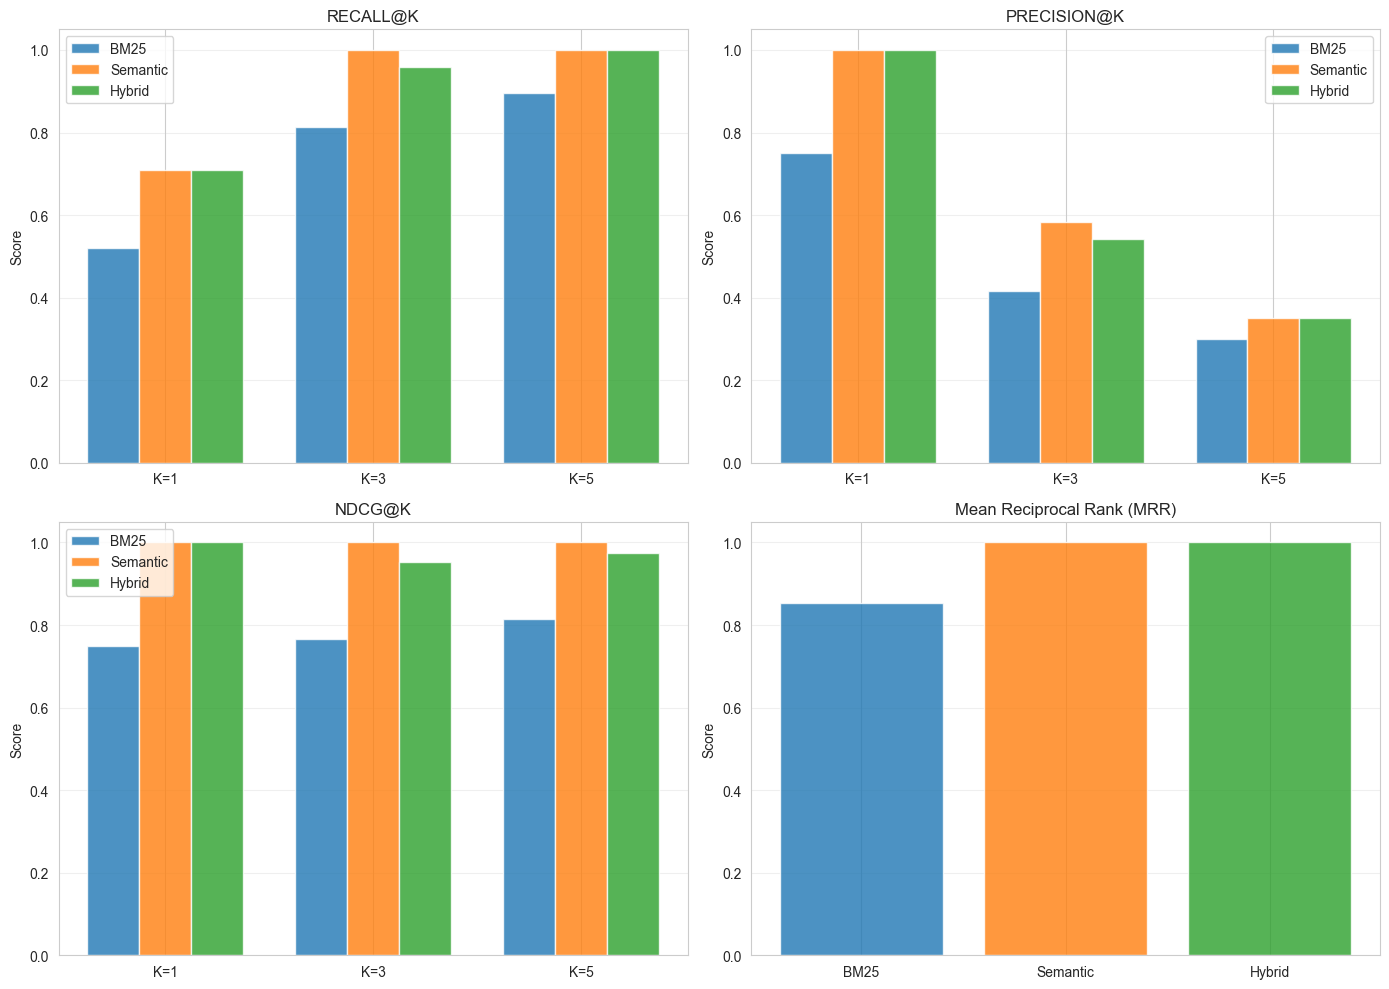

In [23]:
def display_metrics(bm25_metrics, semantic_metrics, hybrid_metrics):
    """
    Display evaluation metrics in a formatted table.
    """
    print("\n" + "="*100)
    print("EVALUATION RESULTS")
    print("="*100)
    
    # Create comparison DataFrame
    data = []
    
    for k in [1, 3, 5]:
        data.append({
            'Metric': f'Recall@{k}',
            'BM25': f"{bm25_metrics['recall'][k]:.3f}",
            'Semantic': f"{semantic_metrics['recall'][k]:.3f}",
            'Hybrid': f"{hybrid_metrics['recall'][k]:.3f}"
        })
        data.append({
            'Metric': f'Precision@{k}',
            'BM25': f"{bm25_metrics['precision'][k]:.3f}",
            'Semantic': f"{semantic_metrics['precision'][k]:.3f}",
            'Hybrid': f"{hybrid_metrics['precision'][k]:.3f}"
        })
        data.append({
            'Metric': f'NDCG@{k}',
            'BM25': f"{bm25_metrics['ndcg'][k]:.3f}",
            'Semantic': f"{semantic_metrics['ndcg'][k]:.3f}",
            'Hybrid': f"{hybrid_metrics['ndcg'][k]:.3f}"
        })
    
    data.append({
        'Metric': 'MRR',
        'BM25': f"{bm25_metrics['mrr']:.3f}",
        'Semantic': f"{semantic_metrics['mrr']:.3f}",
        'Hybrid': f"{hybrid_metrics['mrr']:.3f}"
    })
    
    df = pd.DataFrame(data)
    print("\n", df.to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics_to_plot = ['recall', 'precision', 'ndcg']
    k_values = [1, 3, 5]
    
    for idx, metric_name in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        bm25_values = [bm25_metrics[metric_name][k] for k in k_values]
        semantic_values = [semantic_metrics[metric_name][k] for k in k_values]
        hybrid_values = [hybrid_metrics[metric_name][k] for k in k_values]
        
        x = np.arange(len(k_values))
        width = 0.25
        
        ax.bar(x - width, bm25_values, width, label='BM25', alpha=0.8)
        ax.bar(x, semantic_values, width, label='Semantic', alpha=0.8)
        ax.bar(x + width, hybrid_values, width, label='Hybrid', alpha=0.8)
        
        ax.set_ylabel('Score')
        ax.set_title(f'{metric_name.upper()}@K')
        ax.set_xticks(x)
        ax.set_xticklabels([f'K={k}' for k in k_values])
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    
    # MRR comparison
    ax = axes[1, 1]
    methods = ['BM25', 'Semantic', 'Hybrid']
    mrr_values = [bm25_metrics['mrr'], semantic_metrics['mrr'], hybrid_metrics['mrr']]
    
    ax.bar(methods, mrr_values, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_ylabel('Score')
    ax.set_title('Mean Reciprocal Rank (MRR)')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('retrieval_evaluation.png', dpi=150, bbox_inches='tight')
    print("\n📊 Visualization saved to 'retrieval_evaluation.png'")
    plt.show()

display_metrics(bm25_metrics, semantic_metrics, hybrid_metrics)